In [1]:
import pandas as pd
import numpy as np 


In [2]:
df = pd.read_csv("salary_satisfaction.csv")

In [3]:
df.head()

,Service,Salary
0,excellent,low
1,excellent,low
2,excellent,low
3,excellent,low
4,excellent,low


In [4]:
tab1 = pd.crosstab(df.Service, df.Salary)

In [5]:
tab1

Salary,high,low,medium
Service,,,
excellent,7,9,10
good,31,11,9
poor,3,12,8


In [6]:
from scipy.stats import chi2_contingency   # chi square

In [7]:
chi2_contingency(tab1)

(18.658230409973125,
 0.0009172334128317392,
 4,
 array([[10.66,  8.32,  7.02],
        [20.91, 16.32, 13.77],
        [ 9.43,  7.36,  6.21]]))

In [ ]:
# P value is less than 0.5 then reject the null accept the alternet hypothesis. 

0.0009172334128317392 < 0.5 

# Final conclusion is there is a relation b/w salary paid and service offered


In [ ]:
# Chi square also used for feature selection. 

In [15]:
df.head()

,Service,Salary
0,excellent,low
1,excellent,low
2,excellent,low
3,excellent,low
4,excellent,low


In [23]:
df[df.isnull()]

,Service,Salary
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
95,NaN,NaN
96,NaN,NaN
97,NaN,NaN
98,NaN,NaN


Service    100
Salary     100
dtype: int64

In [92]:
df  = pd.read_csv('CreditRisk.csv')

In [25]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [91]:
df['Load_ID'] = df['Loan_ID'].isnull()

In [30]:
import seaborn as sns

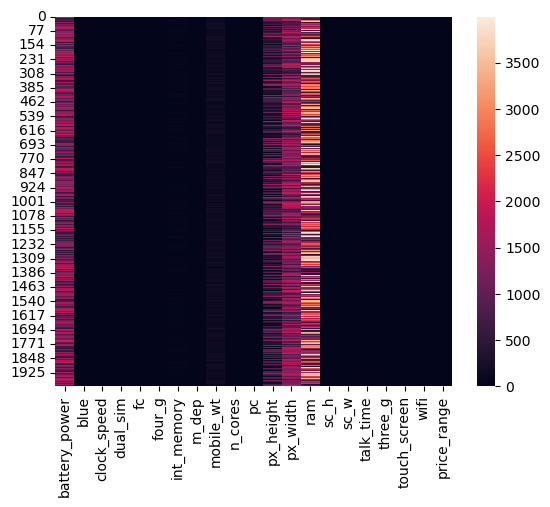

In [89]:
hm = sns.heatmap(data = df)

In [35]:
chi2_contingency(pd.crosstab(df.Education,df.Loan_Status))



(4.796447237106696,
 0.028518487896416037,
 1,
 array([[209.22222222, 553.77777778],
        [ 59.77777778, 158.22222222]]))

In [ ]:
0.028518487896416037  < 0.05

we reject the null -- we go with alternate 

In [ ]:
# Note : 
# Lesser the p value, more confident in rejecting null. 

In [36]:
chi2_contingency(pd.crosstab(df.Gender,df.Loan_Status))


(0.7453383195092128,
 0.3879561718664325,
 1,
 array([[ 49.82654127, 132.17345873],
        [212.17345873, 562.82654127]]))

In [ ]:
0.3879561718664325 < 0.05 

# Ho will not be rejected

In [37]:
chi2_contingency(pd.crosstab(df.Married,df.Loan_Status))


(7.30403598277727,
 0.006879989829483938,
 1,
 array([[ 95.44274029, 251.55725971],
        [173.55725971, 457.44274029]]))

In [40]:
if (0.006879989829483938 < 0.05):
    print("Reject Ho")
else :
    print("Accept Ho")

Reject Ho


In [99]:
emp_Accepted_P_Value = []
emp_column = []
i = 0
for i in df:
    
    P = chi2_contingency(pd.crosstab(df[i],df.Loan_Status))[1]
    print(P)
    
    
    if (P < 0.05):
        print("For Reject Ho")
        emp_Accepted_P_Value.append(P) 
        emp_column.append(df.iloc[ : , i:-1])
        
    else :
        print("Accept Ho")
    print("*" * 30)
    
print(emp_Accepted_P_Value)

0.4849881773492303
Accept Ho
******************************
0.3879561718664325
Accept Ho
******************************
0.006879989829483938
For Reject Ho


TypeError: cannot do positional indexing on Index with these indexers [Married] of type str

In [65]:
X = df.iloc[ : , 0:-1]
Y = df.Loan_Status

In [84]:
empt_list_col = []
empt_list_pvalue = []

for col in X.columns: 
    tab = pd.crosstab(X[col],Y)
    pvalue = chi2_contingency(tab)[1]
    if pvalue < 0.05: 
        empt_list_col.append(col)
        empt_list_pvalue.append(pvalue)

In [85]:
empt_list_col

['battery_power', 'ram', 'sc_w']

In [86]:
empt_list_pvalue

[0.04740658115416354, 5.726600585736166e-13, 0.014914604222894515]

In [71]:
feat_imp = pd.DataFrame()
feat_imp['Features'] = empt_list_col
feat_imp['Imp'] = empt_list_pvalue

In [72]:
feat_imp.sort_values('Imp')

,Features,Imp
8,Credit_History,3.822528e-85
9,Property_Area,4.646576e-04
7,Loan_Amount_Term,6.469817e-03
2,Married,6.879990e-03
3,Education,2.851849e-02
6,LoanAmount,1.974442e-01
1,Gender,3.879562e-01
5,ApplicantIncome,4.157760e-01
4,Self_Employed,4.548271e-01
0,Loan_ID,4.849882e-01


In [73]:
df = pd.read_csv("trainRF.csv")

In [76]:
X = df.iloc[ : , 0:-1]
Y = df.price_range

In [81]:
empt_list_col = []
empt_list_pvalue = []

for col in X.columns: 
    tab = pd.crosstab(X[col],Y)
    pvalue = chi2_contingency(tab)[1]
    if pvalue < 0.05: 
        empt_list_col.append(col)
        empt_list_pvalue.append(pvalue)

In [82]:
feat_imp = pd.DataFrame()
feat_imp['Features'] = empt_list_col
feat_imp['Imp'] = empt_list_pvalue

In [83]:
feat_imp.sort_values('Imp')

,Features,Imp
1,ram,5.726601e-13
2,sc_w,1.491460e-02
0,battery_power,4.740658e-02


In [77]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


### Annova

In [3]:
bulb_life = pd.DataFrame({'A' : (20,19,21),
                         "B" : (25,23,21),
                         "C" : (24,20,22),
                          "D" : (23,20,20)                         
                         })

In [4]:
bulb_life

,A,B,C,D
0,20,25,24,23
1,19,23,20,20
2,21,21,22,20


In [5]:
from scipy.stats import f_oneway  # For annova testing. 

In [6]:
f_oneway(bulb_life.A , bulb_life.B, bulb_life.C, bulb_life.D)

F_onewayResult(statistic=1.6666666666666667, pvalue=0.2503240062160951)

In [ ]:
Conclusion : Since pvalue is more than 0.05 we will accept the null. 

In [28]:
df = pd.read_csv('CreditRisk.csv')

In [8]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0.0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,Y
978,LP002980,Male,No,0.0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,Y
979,LP002986,Male,Yes,0.0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,N


In [ ]:
# prove that education has impact on income statastically. 


In [16]:
f_oneway(df.Education , df.ApplicantIncome) 


F_onewayResult(statistic=811.190891711792, pvalue=1.31774385196307e-149)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    float64
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        981 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 99.8+ KB


In [29]:
dfg = df[df.Education == 'Graduate'] 
dfg.Education.value_counts()

Education
Graduate    763
Name: count, dtype: int64

In [32]:
dfng = df[df.Education == 'Not Graduate'] 
dfg.Education.value_counts()

Education
Graduate    763
Name: count, dtype: int64

In [33]:
f_oneway(dfg.ApplicantIncome , dfng.ApplicantIncome) 


F_onewayResult(statistic=19.262124030897002, pvalue=1.2631725600637295e-05)

Conclusion : as pvalue is greater than 0.05,  we will accept the null. 

In [ ]:
## For Gender income check

In [42]:
md = df[df.Gender == 'Male']
nmd = df[df.Gender == 'Female'] 
f_oneway(md.ApplicantIncome , nmd.ApplicantIncome) 

F_onewayResult(statistic=3.16667779778364, pvalue=0.07547312807353941)

In [43]:
## for Married income check 

xa = df[df.Married == 'Yes']
xaa = df[df.Married == 'No']
f_oneway(xa.ApplicantIncome , xaa.ApplicantIncome) 

F_onewayResult(statistic=2.623926073562529, pvalue=0.10558674253304844)

In [46]:
print(xa.ApplicantIncome.mean())
print(xaa.ApplicantIncome.mean())

5395.464342313788
4778.731988472622


 we can conlude from here that married people has more income 

In [44]:
## for self- employed  income check 

se = df[df.Self_Employed == 'Yes']
nse = df[df.Self_Employed == 'No']
f_oneway(se.ApplicantIncome , nse.ApplicantIncome) 

F_onewayResult(statistic=14.26102746163687, pvalue=0.00016929596084914862)

We accept the null

Self enployed are having more income

## Post hoc Test

In [49]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [51]:
tuckey = pairwise_tukeyhsd(endog= df.ApplicantIncome,
                          groups=df.Education)

In [52]:
print(tuckey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
 group1     group2     meandiff  p-adj   lower      upper    reject
-------------------------------------------------------------------
Graduate Not Graduate -1901.9037   0.0 -2752.3008 -1051.5066   True
-------------------------------------------------------------------


In [57]:
restaurant1 = pd.DataFrame({'sales': [21,41,43,55,45,37,29,49,56,17,48,43,32,33,60,23,91,99,76,60,50],'group': np.repeat(['burger', 'Pizza', 'Sandwich'],repeats=7)}) 

SyntaxError: invalid non-printable character U+00A0 (1760684203.py, line 3)

In [58]:
restaurant1 = pd.DataFrame({'sales': [21,41,43,55,45,37,29,49,56,17,48,43,32,33,60,23,91,99,76,60,50],'group': np.repeat(['burger', 'Pizza', 'Sandwich'],repeats=7)}) 

SyntaxError: invalid non-printable character U+00A0 (598231336.py, line 1)

In [61]:
restorent1 = pd.DataFrame({'Sales':[21,41,43,55,45,37,29,49,56,17,48,43,32,33,60,23,91,99,76,60,50], 'group': np.repeat(['burger', 'Pizza', 'Sandwich'],repeats=7)})
restorent1

,Sales,group
0,21,burger
1,41,burger
2,43,burger
3,55,burger
4,45,burger
5,37,burger
6,29,burger
7,49,Pizza
8,56,Pizza
9,17,Pizza


In [ ]:
df_b = 